In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import uproot
import awkward as ak
import tabulate as tab
import glob
import h5py
from tqdm import tqdm

from scipy.signal import find_peaks


In [2]:
def read_root_files(filepath, cosmics=False, verbose=False):
    file = uproot.open(filepath)
    if verbose: print(file.keys())
    analyszer = 'PNSCRPanalyzercosmics' if cosmics else 'PNSCRPanalyzerflashes1'
    evts = uproot.open(f"{filepath}:{analyszer}/Event")
    akw = evts.arrays(filter_name=evts.keys(), library="ak")
    return akw

def get_info(akw, display=False):
    Nevents    = len(akw['waveformsADC'])
    TrigWindow = len(akw['waveformsADC'][0][0])
    Nchannels  = len(akw['waveformsADC'][0])
    maxima = []
    for chID in range(0, Nchannels):
        maxima.append(ak.max( akw['waveformsADC'][:][chID]) )
    if display:
        print(' trigger reccords:', Nevents)
        print(' trigger window:', TrigWindow)
        print(' number of channels:', Nchannels)
        print(' ADCmax:', int(np.max(maxima)) )
    return Nevents, TrigWindow, Nchannels, maxima

def get_std_trigger_lenght(raw_wfs, chID, verbose=False):
    lengths = ak.to_numpy( ak.num(raw_wfs[:, chID]) )
    values, counts = np.unique(lengths, return_counts=True)
    if verbose:
        print('values', values)
        print('counts', counts, '\n')
    std_length = values[np.argmax(counts)]
    print('standard trigger lenght', std_length)
    percentage = (np.sum(counts) - counts[np.argmax(counts)])*100 / np.sum(counts)
    print(f'percentage of non-standard trigger records: {percentage:.1f} % ( {np.sum(counts) - counts[np.argmax(counts)]} records)')
    return std_length


In [3]:
# --- wrappers ---
def get_raw_waveforms(directory, filename):
    cosmics = False
    if 'cosmic' in filename: cosmics = True
    akw = read_root_files(f'{directory}/{filename}', cosmics=cosmics)
    _, _, _, _ = get_info(akw, display=True)
    return akw['waveformsADC'], cosmics

def save_waveforms(directory, filename, chID, save_to_file=False, outputdir='.', run='r', extra=''):
    # TODO: add also the cases where the lenght of the trigger record is smaller (for now we just throw them away)
    raw_wfs, cosmics = get_raw_waveforms(directory, filename)
    std_trig = get_std_trigger_lenght(raw_wfs, chID=0, verbose=False)
    raw_data = [ak.to_numpy(raw_wfs[i][chID]) for i in range(len(raw_wfs)) if len(ak.to_numpy(raw_wfs[i][chID])) == std_trig]
    
    outputname = f'pns_{run}_chID{chID}'
    if cosmics:
        outputname = f'cosmics_{run}_chID{chID}'
    if extra != '': 
        outputname += f'_{extra}'
    outputname += '.npz'
    print(f'\nsaving {len(raw_data)} waveforms to {outputname}')
    if save_to_file:
        np.savez(
            f'{outputdir}/{outputname}',
            wfs=raw_data,
        )


### PNS

In [ ]:
# path to the file
cernbox = '/Users/emiliebertholet/cernbox/coldbox_data'
# directory = f'{cernbox}/anaCRP_files/raw_files'
# filename = 'ana_pns_r25036_small_31_40.root'
directory = f'{cernbox}/anaCRP_files/raw_files/pns_r25036'
# filename = 'ana_pns_small_90_99.root'

# --- output ---
run = 'r25036' # [0, 1, 2, 3, 4, 5, 6, 7, 8, 10] channels 9 and 11 are BAD
extra = '90-99' # 0-7, 8-16, 17-30, 31-40, 50-59, 60-69, 70_79, 80-89, 90-99 
outputdir = 'pns_raw_files' # pns_raw_files, cosmics_raw_files
## 

for chID in [1]:
    print(chID)
    save_waveforms(directory, filename, chID, save_to_file=True, outputdir=outputdir, run=run, extra=extra)


1
 trigger reccords: 3320
 trigger window: 65600
 number of channels: 12
 ADCmax: 16383
standard trigger lenght 65600
percentage of non-standard trigger records: 1.7 % ( 58 records)

saving 3262 waveforms to pns_r25036_chID1_90-99.npz


### Cosmics

In [5]:
# path to the file
cernbox = '/Users/emiliebertholet/cernbox/coldbox_data'
directory = f'{cernbox}/anaCRP_files/raw_files'
filename = 'ana_cosmic_r25004_small_0_6.root'

# --- output ---
run = 'r25004' # [0, 1, 2, 3, 4, 5, 6, 8, 9, 10] channels 7 and 11 are BAD
extra = '0-6' # 0-6
outputdir = 'cosmics_raw_files' # pns_raw_files, cosmics_raw_files
## 

# for chID in range(0, 12): #[0, 1, 2, 3, 4, 5, 6, 8, 9, 10]
#     save_waveforms(directory, filename, chID, save_to_file=True, outputdir=outputdir, run=run, extra=extra)

 trigger reccords: 588
 trigger window: 262208
 number of channels: 12
 ADCmax: 16383
standard trigger lenght 262208
percentage of non-standard trigger records: 1.4 % ( 8 records)

saving 580 waveforms to cosmics_r25004_chID0_0-6.npz
 trigger reccords: 588
 trigger window: 262208
 number of channels: 12
 ADCmax: 16383
standard trigger lenght 262208
percentage of non-standard trigger records: 1.4 % ( 8 records)

saving 580 waveforms to cosmics_r25004_chID1_0-6.npz
 trigger reccords: 588
 trigger window: 262208
 number of channels: 12
 ADCmax: 16383
standard trigger lenght 262208
percentage of non-standard trigger records: 1.4 % ( 8 records)

saving 580 waveforms to cosmics_r25004_chID2_0-6.npz
 trigger reccords: 588
 trigger window: 262208
 number of channels: 12
 ADCmax: 16383
standard trigger lenght 262208
percentage of non-standard trigger records: 1.4 % ( 8 records)

saving 580 waveforms to cosmics_r25004_chID3_0-6.npz
 trigger reccords: 588
 trigger window: 262208
 number of channe

# Plots from files

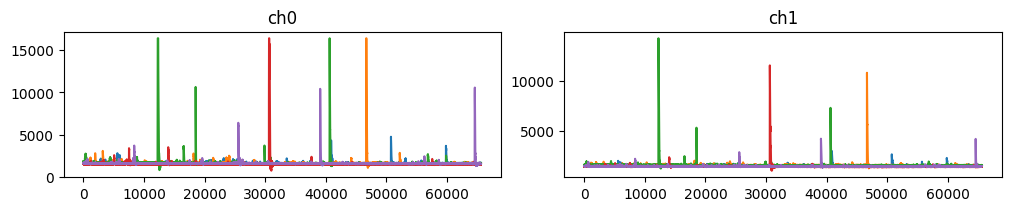

In [13]:
# --- output ---
run = 'r25036' #
extra = '8-16' # 0-7, 8-16, 7-30
directory = 'pns_raw_files' # pns_raw_files, cosmics_raw_files

wfs = []
for chID in range(0, 2): #range(0, 12)
    path = f"{directory}/cosmics_{run}_chID{chID}_{extra}.npz"
    if 'pns' in directory:
        path = f"{directory}/pns_{run}_chID{chID}_{extra}.npz"
    wfs.append( np.load(path)["wfs"] )

# --- plot ---
fig, axs = plt.subplots(1, 2, figsize=(10, 2), constrained_layout=True)
for ch in range(0, 2):
    axs = axs.flatten()
    axs[ch].set_title(f'ch{ch}')
    for rec in range(0, 5):
        axs[ch].plot( wfs[ch][rec] )

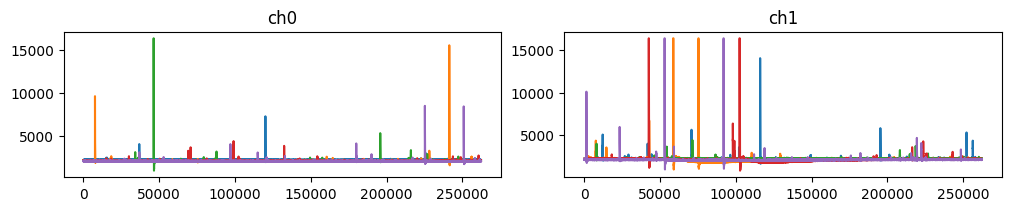

In [15]:
# --- output ---
run = 'r25004' #
extra = '0-6' # 0-7, 8-16, 7-30
directory = 'cosmics_raw_files' # pns_raw_files, cosmics_raw_files

wfs = []
for chID in range(0, 2): #range(0, 12)
    path = f"{directory}/cosmics_{run}_chID{chID}_{extra}.npz"
    if 'pns' in directory:
        path = f"{directory}/pns_{run}_chID{chID}_{extra}.npz"
    wfs.append( np.load(path)["wfs"] )

# --- plot ---
fig, axs = plt.subplots(1, 2, figsize=(10, 2), constrained_layout=True)
for ch in range(0, 2):
    axs = axs.flatten()
    axs[ch].set_title(f'ch{ch}')
    for rec in range(0, 5):
        axs[ch].plot( wfs[ch][rec] )

## Kepp for reference

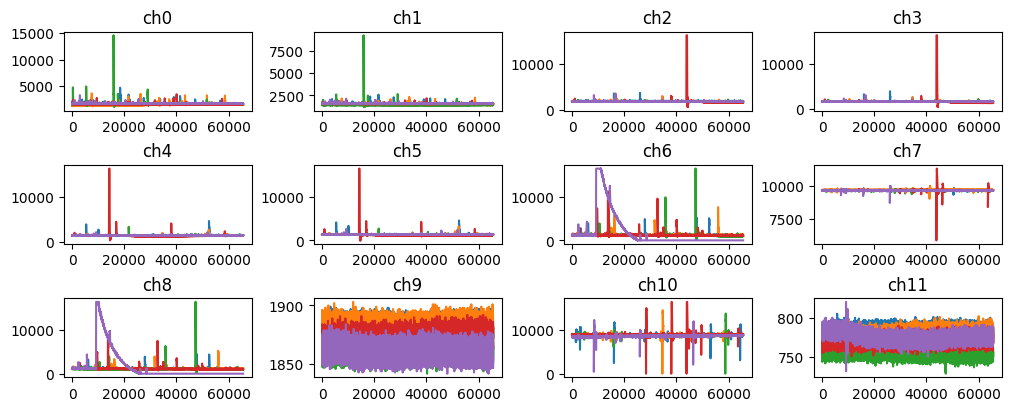

In [6]:
# --- PNS ---
run = 'r25036'
extra = '0-7' 
directory = 'pns_raw_files' 

wfs = []
for chID in range(0, 12): #range(0, 12)
    path = f"{directory}/cosmics_{run}_chID{chID}_{extra}.npz"
    if 'pns' in directory:
        path = f"{directory}/pns_{run}_chID{chID}_{extra}.npz"
    wfs.append( np.load(path)["wfs"] )
    
# --- plot ---
fig, axs = plt.subplots(3, 4, figsize=(10, 4), constrained_layout=True)
for ch in range(0, 12):
    axs = axs.flatten()
    axs[ch].set_title(f'ch{ch}')
    for rec in range(0, 5):
        axs[ch].plot( wfs[ch][rec] )

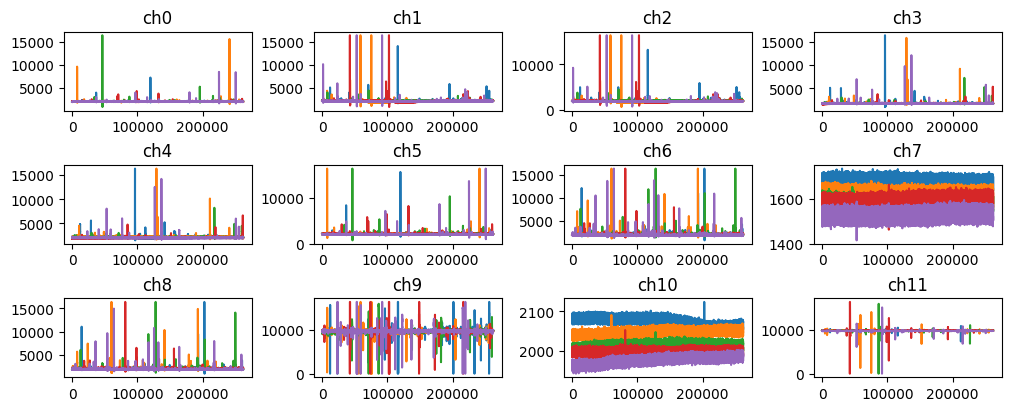

In [8]:
# --- cosmics ---
run = 'r25004'
extra = '0-6' 
directory = 'cosmics_raw_files' 

wfs = []
for chID in range(0, 12): #range(0, 12)
    path = f"{directory}/cosmics_{run}_chID{chID}_{extra}.npz"
    if 'pns' in directory:
        path = f"{directory}/pns_{run}_chID{chID}_{extra}.npz"
    wfs.append( np.load(path)["wfs"] )
    
# --- plot ---
fig, axs = plt.subplots(3, 4, figsize=(10, 4), constrained_layout=True)
for ch in range(0, 12):
    axs = axs.flatten()
    axs[ch].set_title(f'ch{ch}')
    for rec in range(0, 5):
        axs[ch].plot( wfs[ch][rec] )